# 02c — Euclidean lerp in R³ (diagnostic)

**Not** a hyperbolic geodesic — linear interpolation between two projected points.


### Euclidean segment between two vertices (diagnostic)

**Method:** Two vertices’ stereographic images `p0`, `p1` in ℝ³ are joined by a straight line `lerp(t)` in ℝ³. This is **not** a hyperbolic geodesic in native space—only a linear interpolation in the chosen chart.

**How to read the output:** The orange chord is easy to compute but has no direct interpretation as a D-Mercator geodesic. Use it to see whether two proteins appear close in this projection or to debug stereographic outliers (e.g. near the projection pole).


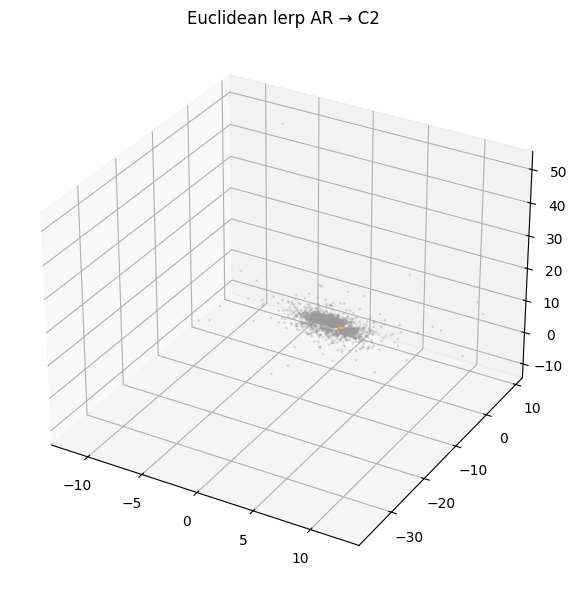

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

import dmercator3d_io as dm
from ball_projection import stereographic_s3_to_r3

merged = dm.load_merged_parquet(Path("cache/merged.parquet"))
U = dm.normalize_direction_nd(merged)
x1, x2, x3, x4 = U[:, 0], U[:, 1], U[:, 2], U[:, 3]
X, Y, Z = stereographic_s3_to_r3(x1, x2, x3, x4, pole="north")
v0, v1 = merged["Vertex"].iloc[0], merged["Vertex"].iloc[1]
m0 = (merged["Vertex"] == v0).to_numpy()
m1 = (merged["Vertex"] == v1).to_numpy()
p0 = np.array([X[m0][0], Y[m0][0], Z[m0][0]])
p1 = np.array([X[m1][0], Y[m1][0], Z[m1][0]])
ts = np.linspace(0, 1, 40)
curve = np.outer(1 - ts, p0) + np.outer(ts, p1)
rng = np.random.default_rng(1)
bg = rng.choice(len(X), size=min(4000, len(X)), replace=False)
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X[bg], Y[bg], Z[bg], s=1, alpha=0.25, c="0.6")
ax.plot(curve[:, 0], curve[:, 1], curve[:, 2], c="orange", lw=2)
ax.set_title(f"Euclidean lerp {v0} → {v1}")
plt.tight_layout()
plt.show()
